In [23]:
import os
import sys
 
PROJECT_ROOT ="/Users/Anna/ecommerce-data-pipeline"

os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("cwd", os.getcwd())

cwd /Users/Anna/ecommerce-data-pipeline


In [26]:
from src.transformation import (
    load_clean_data,
    transform_data
)

from src.churn_target import create_churn_target

from config.paths import CLEAN_RETAIL

In [27]:
df = load_clean_data(CLEAN_RETAIL)

df = transform_data(df)

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,order_value,invoice_year,invoice_month,invoice_hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8


In [28]:
target_df = create_churn_target(df)

target_df.head()

,customer_id,churn
0,12346.0,1
1,12347.0,0
2,12348.0,0
3,12349.0,0
4,12350.0,1


In [29]:

target_df["churn"].value_counts(normalize=True)

churn
0    0.666052
1    0.333948
Name: proportion, dtype: float64

In [30]:
from src.rfm_features import load_rfm

rfm_df = load_rfm()

In [31]:
training_df = rfm_df.merge(
    target_df,
    on="customer_id",
    how="inner"
)

training_df.head()

,customer_id,recency,frequency,avg_order_value,churn
0,12346.0,325,1,77183.60,1
1,12347.0,1,7,615.71,0
2,12348.0,74,4,449.31,0
3,12349.0,18,1,1757.55,0
4,12350.0,309,1,334.40,1


In [32]:
training_df.shape

(4339, 5)

In [33]:
training_df["churn"].value_counts()

churn
0    2890
1    1449
Name: count, dtype: int64

In [34]:
training_df.groupby("churn")["recency"].mean()

churn
0     30.806920
1    212.605935
Name: recency, dtype: float64

In [35]:
training_df.groupby("churn")["frequency"].mean()

churn
0    5.483391
1    1.855763
Name: frequency, dtype: float64

In [36]:
training_df.groupby("churn")["avg_order_value"].mean()

churn
0    427.805547
1    401.580331
Name: avg_order_value, dtype: float64

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

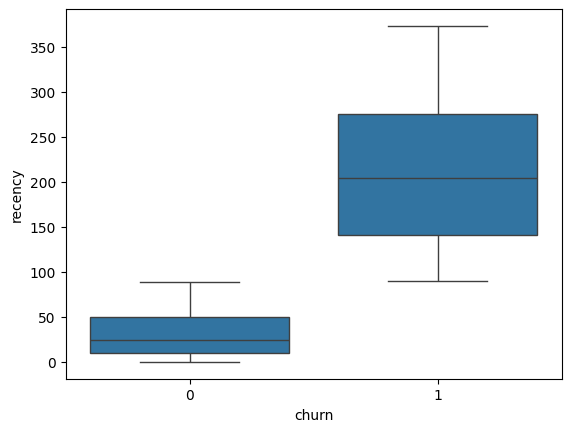

In [38]:
sns.boxplot(
    data=training_df,
    x="churn",
    y="recency"
)

plt.show()

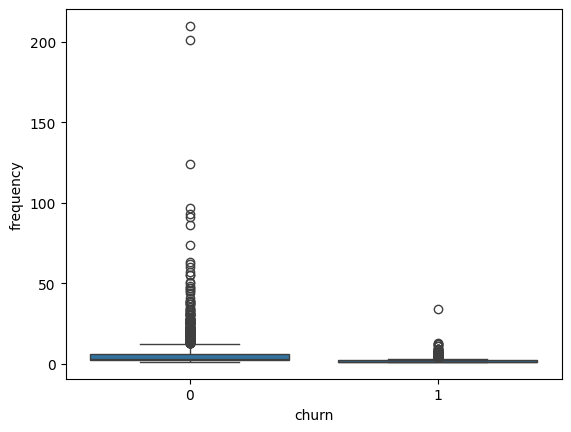

In [ ]:
sns.boxplot(
    data=training_df,
    x="churn",
    y="frequency"
)

plt.show()

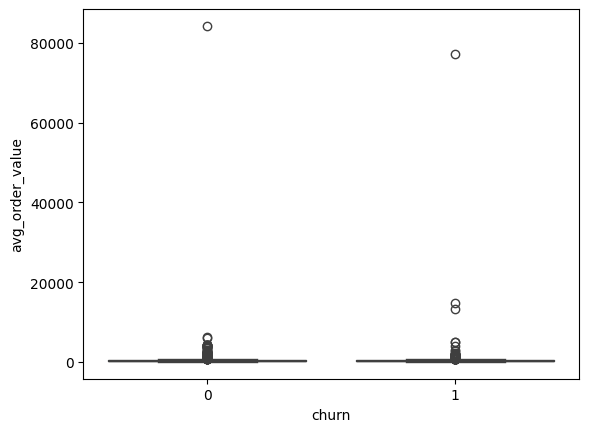

In [ ]:
sns.boxplot(
    data=training_df,
    x="churn",
    y="avg_order_value"
)

plt.show()

In [39]:
training_df.groupby("churn")[
    ["recency", "frequency", "avg_order_value"]
].mean()

,recency,frequency,avg_order_value
churn,,,
0,30.806920,5.483391,427.805547
1,212.605935,1.855763,401.580331


In [40]:
X = training_df[
    ["recency", "frequency", "avg_order_value"]
]

y = training_df["churn"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
   X,
   y,
   test_size=0.2, 
   random_state=42,
   stratify=y
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)


LogisticRegression(random_state=42)

In [45]:
y_pred = model.predict(X_test_scaled)

In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.9919354838709677


In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       578
           1       1.00      0.98      0.99       290

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



In [48]:
import pandas as pd

pd.DataFrame({
    "feature":X.columns,
    "coefficient":model.coef_[0]
})

,feature,coefficient
0,recency,11.453798
1,frequency,0.080837
2,avg_order_value,-0.627089
